In [12]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import matplotlib.cm as cm
import ast

from protocols import utils, functions

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Run grid search on the Entire dataset (training + validation)

We want to release a catalogue built on the entire dataset, and therefore need to run a gridsearch also on the entire dataset.

Code mostly the same as `02-grid-search.ipynb`

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 8

In [7]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    train_phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=False)
    val_phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=True)
    
    #combine training and validation samples into one dataset
    phenotypes = pd.concat([train_phenotypes, val_phenotypes])

    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]: #PWF: only one p-value for now, removed 0.95
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [8]:
if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.4.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.parquet",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search",
      0.1,
      'v3.4.0',
      'v3.4.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/MTBC-CRyPTICv3.4.0-2025.8_grid_results.csv')

else: 
   
   df = pd.read_csv('results/grid_search/MTBC-CRyPTICv3.4.0-2025.8_grid_results.csv')

df[:10]

OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.15_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/bdq/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/bdq/bg_0.15_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cap/bg_0.15_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cap/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.2_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.05_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/ami/bg_0.05_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.2_p_0.95_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/cip/bg_0.1_p_0.9_FRS_0.1.csv
OUTFILE catalogues/MTBC-CRyPTICv3.4.0-202

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,AMI,0.05,0.90,0.877747,0.984234,0.926044,0.856186,0.985470
1,AMI,0.05,0.95,0.877635,0.984320,0.925896,0.855293,0.985551
2,AMI,0.10,0.90,0.862365,0.984874,0.958099,0.853506,0.985551
3,AMI,0.10,0.95,0.862365,0.984853,0.956877,0.853506,0.985551
4,AMI,0.15,0.90,0.861212,0.985566,0.961504,0.850826,0.986157
5,AMI,0.15,0.95,0.861601,0.985551,0.960542,0.850826,0.986157
6,AMI,0.20,0.90,0.861212,0.985594,0.963170,0.850826,0.986157
7,AMI,0.20,0.95,0.861212,0.985566,0.961504,0.850826,0.986157
8,AMI,0.25,0.90,0.860434,0.985642,0.966205,0.850826,0.986157
9,AMI,0.25,0.95,0.861212,0.985601,0.963614,0.850826,0.986157


In [9]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)
melted_df

,DRUG,BACKGROUND_RATE,p_value,Metric,value
0,AMI,0.05,0.90,SENSITIVITY,87.774725
1,AMI,0.05,0.95,SENSITIVITY,87.763520
2,AMI,0.10,0.90,SENSITIVITY,86.236462
3,AMI,0.10,0.95,SENSITIVITY,86.236462
4,AMI,0.15,0.90,SENSITIVITY,86.121157
...,...,...,...,...,...
475,STM,0.15,0.95,DPR,90.631263
476,STM,0.20,0.90,DPR,90.720330
477,STM,0.20,0.95,DPR,89.851926
478,STM,0.25,0.90,DPR,89.829659


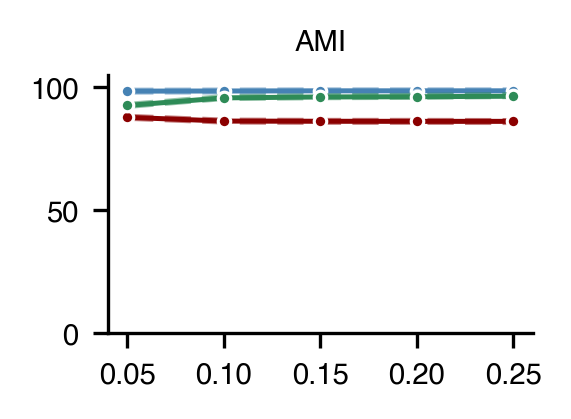

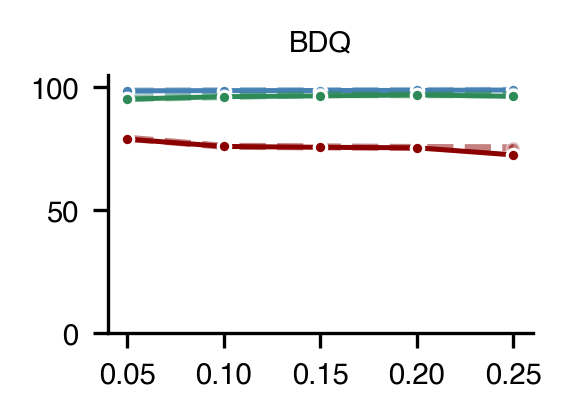

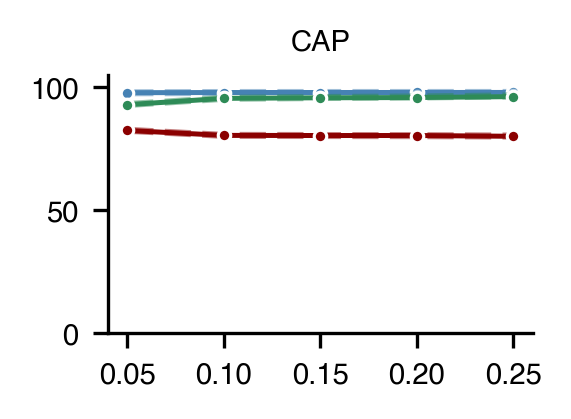

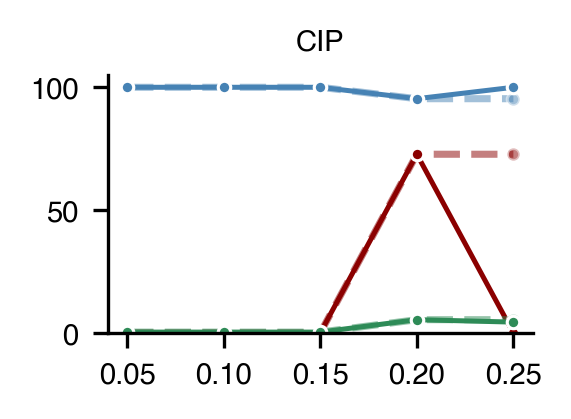

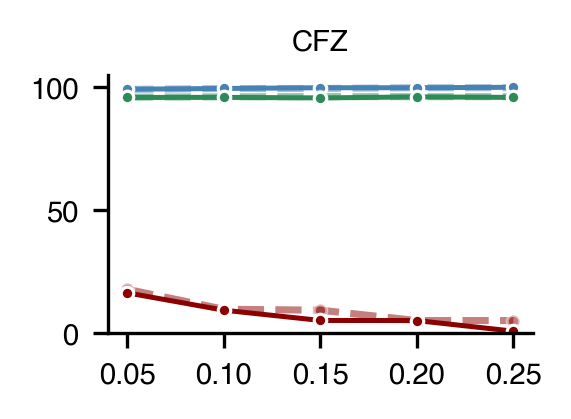

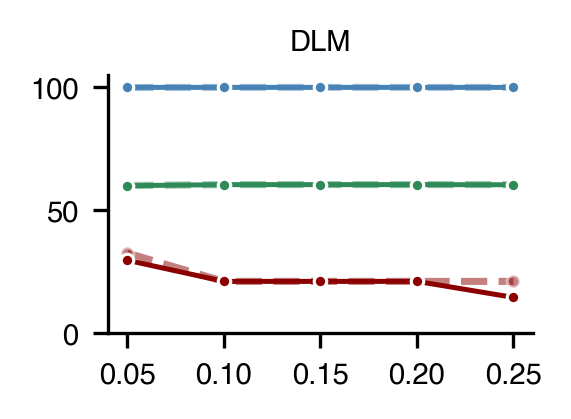

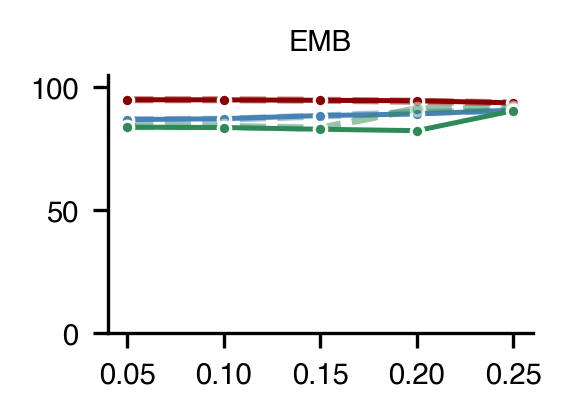

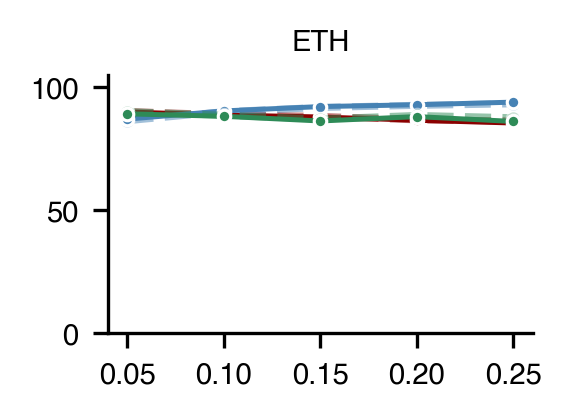

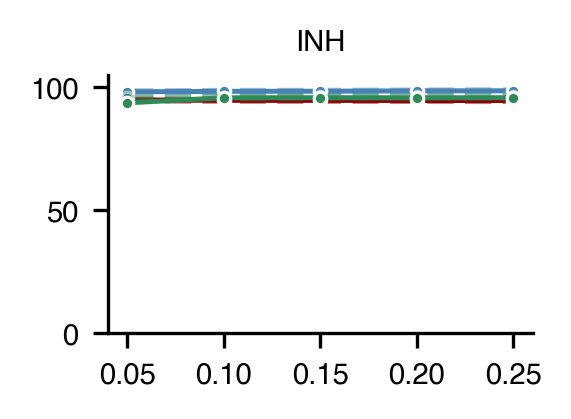

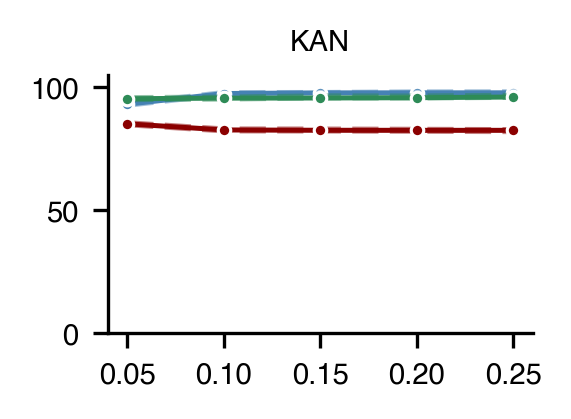

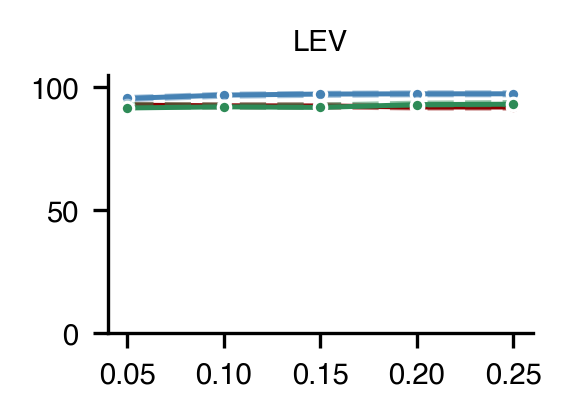

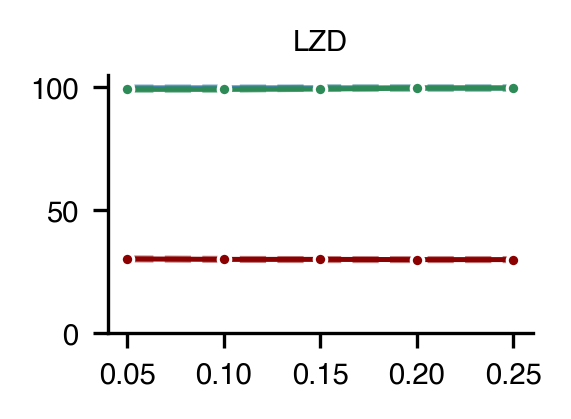

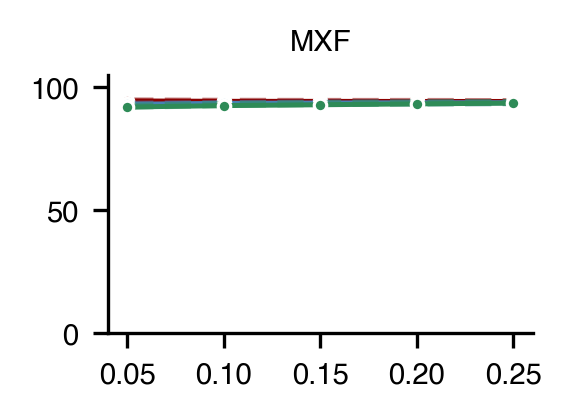

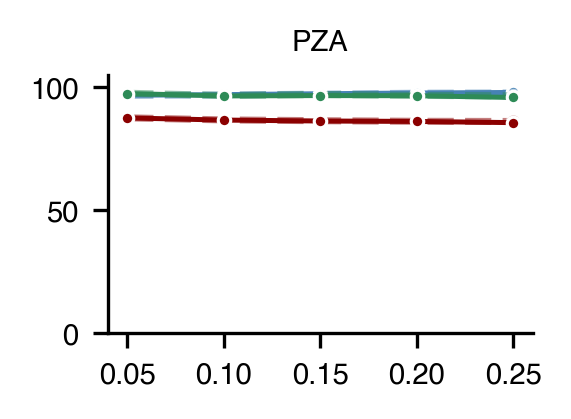

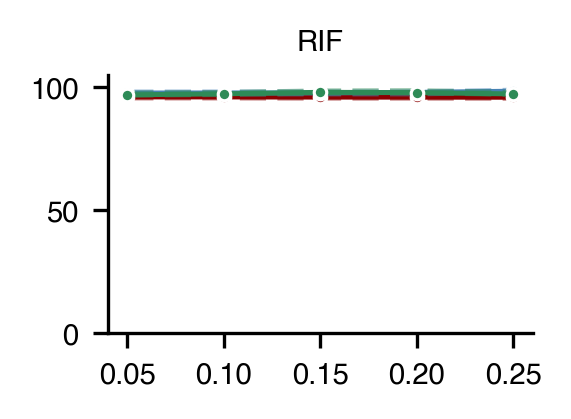

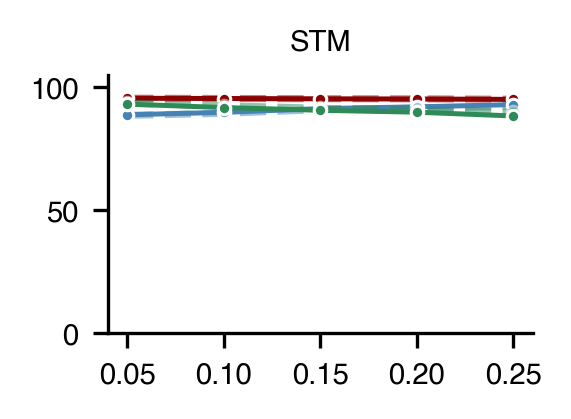

In [10]:

metric_colors = {
    "SENSITIVITY": "#8B0000",  # dark red
    "SPECIFICITY": "#4682B4",  # steel blue
    "DPR": "#2E8B57"           # sea green
}
for drug in melted_df["DRUG"].unique():
    drug_data = melted_df[melted_df["DRUG"] == drug]

    plt.figure(figsize=(2, 1.5))

    for metric in drug_data["Metric"].unique():
        for p in drug_data["p_value"].unique():
            subset = drug_data[
                (drug_data["Metric"] == metric) &
                (drug_data["p_value"] == p)
            ]
            sns.lineplot(
                data=subset,
                x="BACKGROUND_RATE",
                y="value",
                color=metric_colors[metric],
                alpha=0.5 if p == 0.90 else 1.0,  # Example: faded for 0.90, solid for 0.95
                marker="o",
                linestyle="--" if p == 0.90 else "-",  # Dashed for 0.90
                markersize=3,
                linewidth=1.7 if p == 0.9 else 1.2
            )

    plt.title(drug, fontsize=7)
    plt.xlabel("")
    plt.ylabel("")  # No y-label
    plt.ylim(0, 105)
    plt.tick_params(labelsize=7)
    sns.despine(top=True, right=True)
    plt.xticks(np.arange(0.05, 0.26, 0.05))  

    plt.tight_layout()
    #plt.savefig(f'figs/grid_search/{drug}.pdf', transparent=True)

    plt.show()
    plt.close()


# Use weighted score to choose best performing catalogue

In [13]:


# Step 1: Select the best performing catalogue for each DRUG
opt_cats = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

# Step 2: Pull out R, S, U counts from each filtered catalogue
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats['DRUG'][i],
        "R": filtered_cat["PREDICTION"].value_counts().get("R", 0),
        "S": filtered_cat["PREDICTION"].value_counts().get("S", 0),
        "U": filtered_cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(filtered_cat)
    }
    for i in opt_cats.index
    for cat in [pd.read_csv(
        f"./catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/"
        f"{opt_cats['DRUG'][i].lower()}/"
        f"bg_{opt_cats['BACKGROUND_RATE'][i]}_p_{opt_cats['p_value'][i]}_FRS_0.1.csv"
    )]
    for filtered_cat in [cat[cat['EVIDENCE'].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})]]
])

# Step 3: Merge and export
opt_cats = pd.merge(opt_cats, cat_counts, on='DRUG')
opt_cats['catalogue'] = 'MTBC-CRyPTICv3.4.0-2025.8'
opt_cats.to_csv('results/grid_search/opt_cats_MTBC-CRyPTICv3.4.0-2025.8.csv', index=False)
opt_cats


,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.25,0.90,0.959516,0.983928,0.974702,0.942673,0.984392,0.969877,47,25,389,461,MTBC-CRyPTICv3.4.0-2025.8
1,INH,0.20,0.90,0.946292,0.985017,0.961145,0.926351,0.985769,0.960880,86,22,714,822,MTBC-CRyPTICv3.4.0-2025.8
2,MXF,0.25,0.90,0.941687,0.937332,0.938199,0.910808,0.941539,0.939683,12,32,611,655,MTBC-CRyPTICv3.4.0-2025.8
3,LEV,0.25,0.90,0.919437,0.973488,0.933771,0.884500,0.975402,0.938519,12,22,394,428,MTBC-CRyPTICv3.4.0-2025.8
4,STM,0.15,0.90,0.953480,0.909160,0.914384,0.903127,0.918497,0.932365,135,9,613,757,MTBC-CRyPTICv3.4.0-2025.8
5,EMB,0.20,0.90,0.943092,0.897554,0.912953,0.896798,0.907336,0.923403,23,45,1164,1232,MTBC-CRyPTICv3.4.0-2025.8
6,PZA,0.05,0.90,0.875633,0.966762,0.975638,0.866854,0.967671,0.922973,554,0,165,719,MTBC-CRyPTICv3.4.0-2025.8
7,AMI,0.05,0.90,0.877747,0.984234,0.926044,0.856186,0.985470,0.919353,10,6,470,486,MTBC-CRyPTICv3.4.0-2025.8
8,KAN,0.20,0.90,0.824883,0.977227,0.960220,0.810601,0.978195,0.897654,9,16,479,504,MTBC-CRyPTICv3.4.0-2025.8
9,CAP,0.05,0.90,0.824950,0.977598,0.929635,0.793037,0.979243,0.891681,63,2,307,372,MTBC-CRyPTICv3.4.0-2025.8


In [14]:
print('Total number of non-U rows:', opt_cats[['R', 'S']].to_numpy().sum())

Total number of non-U rows: 1525


In [15]:
rows = []

#Although we have run a grid search on all samples, we will use parameters from v1.1.1 
#this allows us to understand what happens when only the underlying data changes
opt_cats = pd.read_csv('results/grid_search/opt_cats_MTBC-CRyPTICv3.4.0-2025.8.csv')

for idx,row in opt_cats.iterrows():
    cat_path = pathlib.Path( "./catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{row.p_value}_FRS_0.1.csv"
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'MTBC-CRyPTICv3.4.0-2025.8'
cat.CATALOGUE_VERSION = '1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/MTBC-CRyPTICv3.4.0-2025.8.csv',index=False)
cat


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.010101010101010102, ""confiden...",{}
1,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [-3.33282421...",{}
2,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1372...",{}
3,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@E563D,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.2129...",{}
4,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.050505050505050504, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
297,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
298,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
299,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
300,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}
